In [86]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np


<div class="alert alert-block alert-info">
<b>__Import Results_marathon.csv__</b> 
</div>



In [87]:
marathon_df = pd.read_csv("Data/Results_marathon.csv")
marathon_df.tail()
#

,Race,Year,Name,Gender,Age,Finish,Age Bracket
779280,Marine Corps Marathon,2019,Daryl Young,M,39,18575,35-39
779281,Marine Corps Marathon,2019,Ella Biggins,F,24,18575,Under 35
779282,Marine Corps Marathon,2019,Kevin Klym,M,44,18575,40-44
779283,Marine Corps Marathon,2019,Casey A Shapiro,F,34,18578,Under 35
779284,Marine Corps Marathon,2019,Zhaowei Liu,M,64,18578,60-64


In [88]:
marathon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779285 entries, 0 to 779284
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Race         779285 non-null  object
 1   Year         779285 non-null  int64 
 2   Name         779285 non-null  object
 3   Gender       779280 non-null  object
 4   Age          779285 non-null  int64 
 5   Finish       779285 non-null  int64 
 6   Age Bracket  779285 non-null  object
dtypes: int64(3), object(4)
memory usage: 41.6+ MB


In [89]:
marathon_df.shape

(779285, 7)

In [90]:
#drop ages younger than 17 and older than 98


def official_ages(marathon_df):
    valid_ages = (marathon_df['Age'] >= 17) & (marathon_df['Age'] <= 98)
    official_ages = marathon_df[valid_ages]

    return official_ages

official_ages

<function __main__.official_ages(marathon_df)>

In [91]:
# verify ages were dropped

valid_age_range = official_ages(marathon_df)

unique_ages = sorted(valid_age_range['Age'].unique())
unique_ages


[np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(68),
 np.int64(69),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(73),
 np.int64(74),
 np.int64(75),
 np.int64(76),
 np.int64(77),
 np.int64(78),
 np.int64(79),
 np.int64(80),
 np.int64(81),
 np.int64(82),
 np.int64(

In [92]:
# recheck nulls 

marathon_df.isnull().sum()


Race           0
Year           0
Name           0
Gender         5
Age            0
Finish         0
Age Bracket    0
dtype: int64

In [93]:
marathon_df = marathon_df.dropna()

In [94]:
# recheck nulls 

marathon_df.isnull().sum()

Race           0
Year           0
Name           0
Gender         0
Age            0
Finish         0
Age Bracket    0
dtype: int64

In [95]:
# Check if there are any duplicates

marathon_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
779280    False
779281    False
779282    False
779283    False
779284    False
Length: 779280, dtype: bool

In [96]:
# Rename Gender column to Sex

marathon_df.rename(columns={'Gender': 'Sex'}, inplace=True)
marathon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779280 entries, 0 to 779284
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Race         779280 non-null  object
 1   Year         779280 non-null  int64 
 2   Name         779280 non-null  object
 3   Sex          779280 non-null  object
 4   Age          779280 non-null  int64 
 5   Finish       779280 non-null  int64 
 6   Age Bracket  779280 non-null  object
dtypes: int64(3), object(4)
memory usage: 47.6+ MB


In [97]:
# Assign Male and Female to M and F

marathon_df['Sex'] = marathon_df["Sex"].replace(['M', 'F'], ['Male', 'Female'])
marathon_df

,Race,Year,Name,Sex,Age,Finish,Age Bracket
0,Richmond Marathon,2019,DAWN STADNYK,Female,43,12847,40-44
1,Richmond Marathon,2019,ANDREW MARTIN,Male,27,12812,Under 35
2,Richmond Marathon,2019,CAROL BRAUN,Female,56,12844,55-59
3,Richmond Marathon,2019,PETER EMERSON,Male,29,12816,Under 35
4,Richmond Marathon,2019,JACOB BARKER,Male,18,12831,Under 35
...,...,...,...,...,...,...,...
779280,Marine Corps Marathon,2019,Daryl Young,Male,39,18575,35-39
779281,Marine Corps Marathon,2019,Ella Biggins,Female,24,18575,Under 35
779282,Marine Corps Marathon,2019,Kevin Klym,Male,44,18575,40-44
779283,Marine Corps Marathon,2019,Casey A Shapiro,Female,34,18578,Under 35


<div class="alert alert-block alert-success">
<b>__Import Results_um.csv__</b> 
</div>

In [98]:
um_df = pd.read_csv("Data/Results_um.csv")
um_df.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:51 h,Team GG,RSA,1985.0,M,M23,5.381,266403
1,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:58 h,Team GG,GBR,1986.0,M,M23,5.381,266404
2,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:02 h,MAD Pat'S Brigade,GBR,1972.0,M,M45,4.386,266406
3,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:07 h,MAD Pat'S Brigade,GBR,1959.0,F,W55,4.386,266407
4,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:16:08 h,MAD Pat'S Brigade,GBR,1962.0,M,M55,4.368,266409


In [99]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
dtypes: float64(1), int64(3), obje

Years are in the order that they appear in the data set

In [100]:
# verify years 

um_df['Year of event'].unique()

array([2018, 2016, 2017, 2019, 2020, 2021, 2022])

In [101]:
# Split Gender category into Athlete age category and Age

um_df['Gender category'] = um_df['Athlete age category'].str.extract(r'([A-Za-z]+)')
um_df['Age'] = um_df['Athlete age category'].str.extract(r'(\d+)').astype(int)


In [102]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Gender category            34

In [103]:
# Find the age categories

um_df['Athlete age category'].unique()

array(['M23', 'M45', 'W55', 'M55', 'W35', 'W23', 'M50', 'M35', 'M60',
       'W45', 'M40', 'MU23', 'W40', 'M65', 'M70', 'W50', 'W60', 'W65',
       'WU23', 'M85', 'W30', 'M20', 'M30', 'W20', 'M75', 'W70', 'W75',
       'M80', 'MU20', 'M90', 'W80', 'WU20'], dtype=object)

In [104]:
# Find birth years

um_df['Athlete year of birth'].unique()

array([1985., 1986., 1972., 1959., 1962., 1961., 1982., 1963., 1965.,
       1987., 1980., 1955., 1988., 1984., 1971., 1969., 1968., 1974.,
       1977., 1989., 1997., 1975., 1966., 1957., 1967., 1973., 1960.,
       1979., 1983., 1978., 1970., 1964., 1950., 1991., 1958., 1976.,
       1956., 1952., 1953., 1949., 1947., 1996., 1993., 1994., 1990.,
       1992., 1954., 1951., 1981., 1995., 1999., 2006., 2003., 2005.,
       1948., 2001., 1933., 1938., 1944., 1998., 2000., 1943., 1946.,
       2004., 1939., 1945., 2002., 1936., 1942., 1941., 1940., 1937.,
       1929., 1931., 1935., 1922., 1934., 2014., 2009., 2008., 2011.,
       2007., 2010.])

In [105]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Gender category            34

In [106]:
um_df['Age'].unique()

array([23, 45, 55, 35, 50, 60, 40, 65, 70, 85, 30, 20, 75, 80, 90])

In [107]:
# Drop Gender category

um_df = um_df.drop("Gender category", axis='columns')

In [108]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Age                        34

In [109]:
# Find the Distance and lenghts of races included

um_df['Event distance/length'].unique()

array(['106km', '80km', '50km', '40mi', '60km', '53km', '55km', '8h',
       '45km', '58km', '6h', '88km', '100km', '72km', '32mi', '30mi',
       '12h', '49.2km', '73km', '48km', '55.8km', '63.3km', '46km',
       '63km', '50mi', '57km', '105km', '45.2km', '105.6km', '129.8km',
       '81km', '158km/3Etappen', '45.4km', '48.5km', '45.1km', '45.5km',
       '46.6km', '35mi', '52km', '51.4km', '56km', '55.7km', '47km',
       '9:11h', '88km/2Etappen', '64km', '75km', '45mi', '85km', '65km',
       '45.8km', '370km/8Etappen', '112km', '52.4mi', '51mi', '34mi',
       '49km', '78km', '54km', '51km', '52.6km', '69km', '65.8km', '33mi',
       '61km', '63.6km', '101km', '64.6km', '55mi', '9h', '62km', '70km',
       '57.8km', '76km', '118km', '54.4km', '84km', '90km', '52mi',
       '50.9km', '103km', '60.2km', '103.5km', '173km/4Etappen', '11:43h',
       '45.18km', '57.2km', '67km', '24h', '67.4km', '85.6km', '132km',
       '97km', '47.6km', '110km', '66km', '15h', '51.5km', '83km',
    

In [110]:
# create new csv with changes 

um_df.to_csv('Results_um1.csv', index=False)

<div class="alert alert-block alert-warning">
<b>Marathon vs Ultra Marathon average age<b>
</div>


In [111]:
# find average age in fall marathons 2016*2019

average_age_by_year = marathon_df.groupby('Year')['Age'].mean()
average_age_by_year

Year
2016    39.765227
2017    40.511194
2018    39.364261
2019    39.563117
Name: Age, dtype: float64

In [112]:
# drop years post 2019 in um_df

um_df = um_df[um_df['Year of event'] <= 2019]

In [113]:
um_df[um_df['Age'] < 25].value_counts('Age')


Age
23    54028
20      419
Name: count, dtype: int64

In [114]:
um_df[um_df['Age'] > 80].value_counts('Age')

Age
85    2
90    1
Name: count, dtype: int64

In [115]:
# Find average age in Fall Ultra Marathons 2016-2019

um_average_age_by_year = um_df.groupby('Year of event')['Age'].mean()
um_average_age_by_year

Year of event
2016    38.988369
2017    38.252173
2018    38.216062
2019    38.544963
Name: Age, dtype: float64

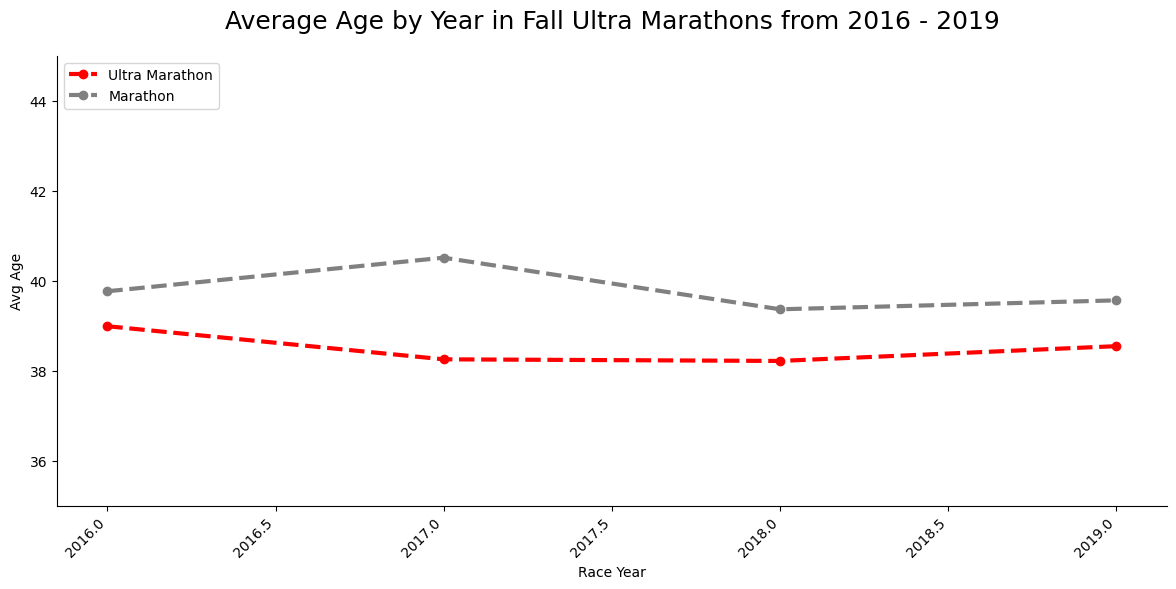

In [116]:
# Plot the average age by year for Fall Ultra Marathons 2016-2022

plt.figure(figsize=(12, 6))
plt.plot(
    um_average_age_by_year.index, 
    um_average_age_by_year.values,
    marker="o",
    linestyle = "--",
    color = "#ff0000",
    linewidth = 3)

plt.plot(
    average_age_by_year.index,
    average_age_by_year.values,
    marker="o",
    linestyle = "--",
    color = "grey",
    linewidth = 3)


plt.xlabel("Race Year")
plt.ylabel("Avg Age")
plt.title("Average Age by Year in Fall Ultra Marathons from 2016 - 2019", fontsize = 18, pad=20)
plt.xticks(rotation=45, ha ="right")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(["Ultra Marathon", "Marathon"], loc="upper left")


plt.tight_layout()

plt.ylim(35, 45)
plt.show()

I am suprised that the marathon has an average participation from older age brackets

<div class="alert alert-block alert-danger">
<b>Now that we have the averages of marathoners and ultra marathoners from 2016-2019, we compare those ages to the average adult runner using myself and my 2019 Indianapolis Monumental Marathon. Unforturnately 2020 happend, but 1 year later I was registered for the BigFoot 50k in December at Salt Fork State Park OH.</b> 
</div>


In [117]:
# narrow dataset down to the marathon I completed

monumental_marathon_2019 = marathon_df[(marathon_df['Year'] == 2019) & (marathon_df['Race'] == 'Indianapolis Monumental Marathon')]
monumental_marathon_2019.head()

,Race,Year,Name,Sex,Age,Finish,Age Bracket
7838,Indianapolis Monumental Marathon,2019,Rachael Meyer,Female,24,15494,Under 35
7839,Indianapolis Monumental Marathon,2019,Andrea Kjos,Female,39,15495,35-39
7840,Indianapolis Monumental Marathon,2019,Renee Guthrie,Female,39,15495,35-39
7841,Indianapolis Monumental Marathon,2019,Jesse Maas,Female,24,15501,Under 35
7842,Indianapolis Monumental Marathon,2019,Tony Blevins,Male,44,15502,40-44


In [118]:
# create a csv of Indy Monumental

monumental_marathon_2019.to_csv('Indianapolis Monumental Marathon 2019')

In [119]:
my_time = monumental_marathon_2019.iloc[2245]
my_time

Race           Indianapolis Monumental Marathon
Year                                       2019
Name                             Justin Masters
Sex                                        Male
Age                                          39
Finish                                    24716
Age Bracket                               35-39
Name: 182310, dtype: object

In [120]:
# Get average of all ages in all years

my_age = 39
total_avg_age = marathon_df['Age'].mean().astype(int)
total_avg_age


np.int64(39)

In [121]:
um_average_age = um_avg_age = um_df['Age'].mean().astype(int)
um_average_age

np.int64(38)

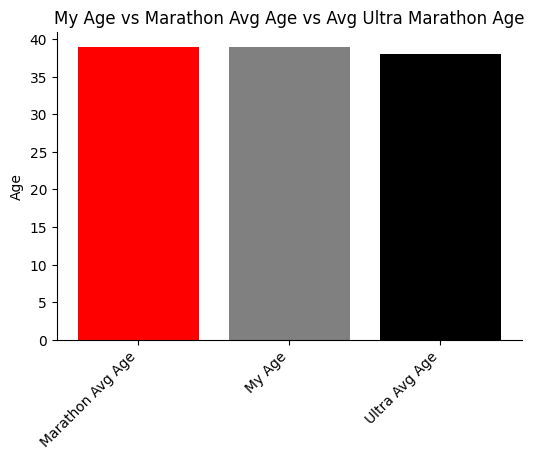

In [122]:
# compare my age to avg age for marathon finishers 2015*2019

plt.figure(figsize=(6,4))
plt.bar(['Marathon Avg Age', 'My Age', 'Ultra Avg Age'], [total_avg_age, my_age, um_average_age], color=['red', 'grey', 'black'])
plt.ylabel('Age')
plt.title('My Age vs Marathon Avg Age vs Avg Ultra Marathon Age')
plt.xticks(rotation=45, ha ="right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

<div class="alert alert-block alert-danger">
<b>As we can see from the above graph, at the age of 39 I was the average age of a marathoner from 2016-2019, and had I been able to participate in the 50k I would have been 2 years older than the average ultra marathoner</b> 
</div>



In [123]:
# Function to assing age bracket and create Age Bracket column used later for a sql join 

def athlete_age_category(age):
    if 17 <= age <= 20:
        return "17-20"
    elif age >= 20 and age <= 25:
        return "21-25"
    elif 26 <= age <= 29:
        return "26-29"
    elif age >= 30 and age < 35:
        return "30-34"
    elif age >= 35 and age < 40:
        return "35-39"
    elif age >= 40 and age < 45:
        return "40-44"
    elif age >= 45 and age < 50:
        return "45-49"
    elif age >= 50 and age < 55:
        return "50-54"
    elif age >= 55 and age < 60:
        return "55-59"
    elif age >= 60 and age < 65:
        return "60-64"
    elif age >= 65 and age < 70:
        return "65-69"
    elif age >= 70 and age < 75:
        return "70-74"
    elif age >= 75 and age < 80:
        return "75-79"
    elif age >= 80 and age < 85:
        return "80-84"
    elif age >= 85 and age < 90:
        return "85-89"
    else:
        return "90+"
    
um_df['Age Bracket'] = um_df['Age'].map(athlete_age_category)


<div class="alert alert-block alert-success">
<b>In the below graph, we see where the United States falls within the age distribution of ultra marathoners by age.</b> 
</div>



/var/folders/77/qj38nbbs3bq7mscbtmmv1lzw0000gn/T/ipykernel_16888/1472392012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age', y='Athlete country', data=um_df, palette=my_colors)


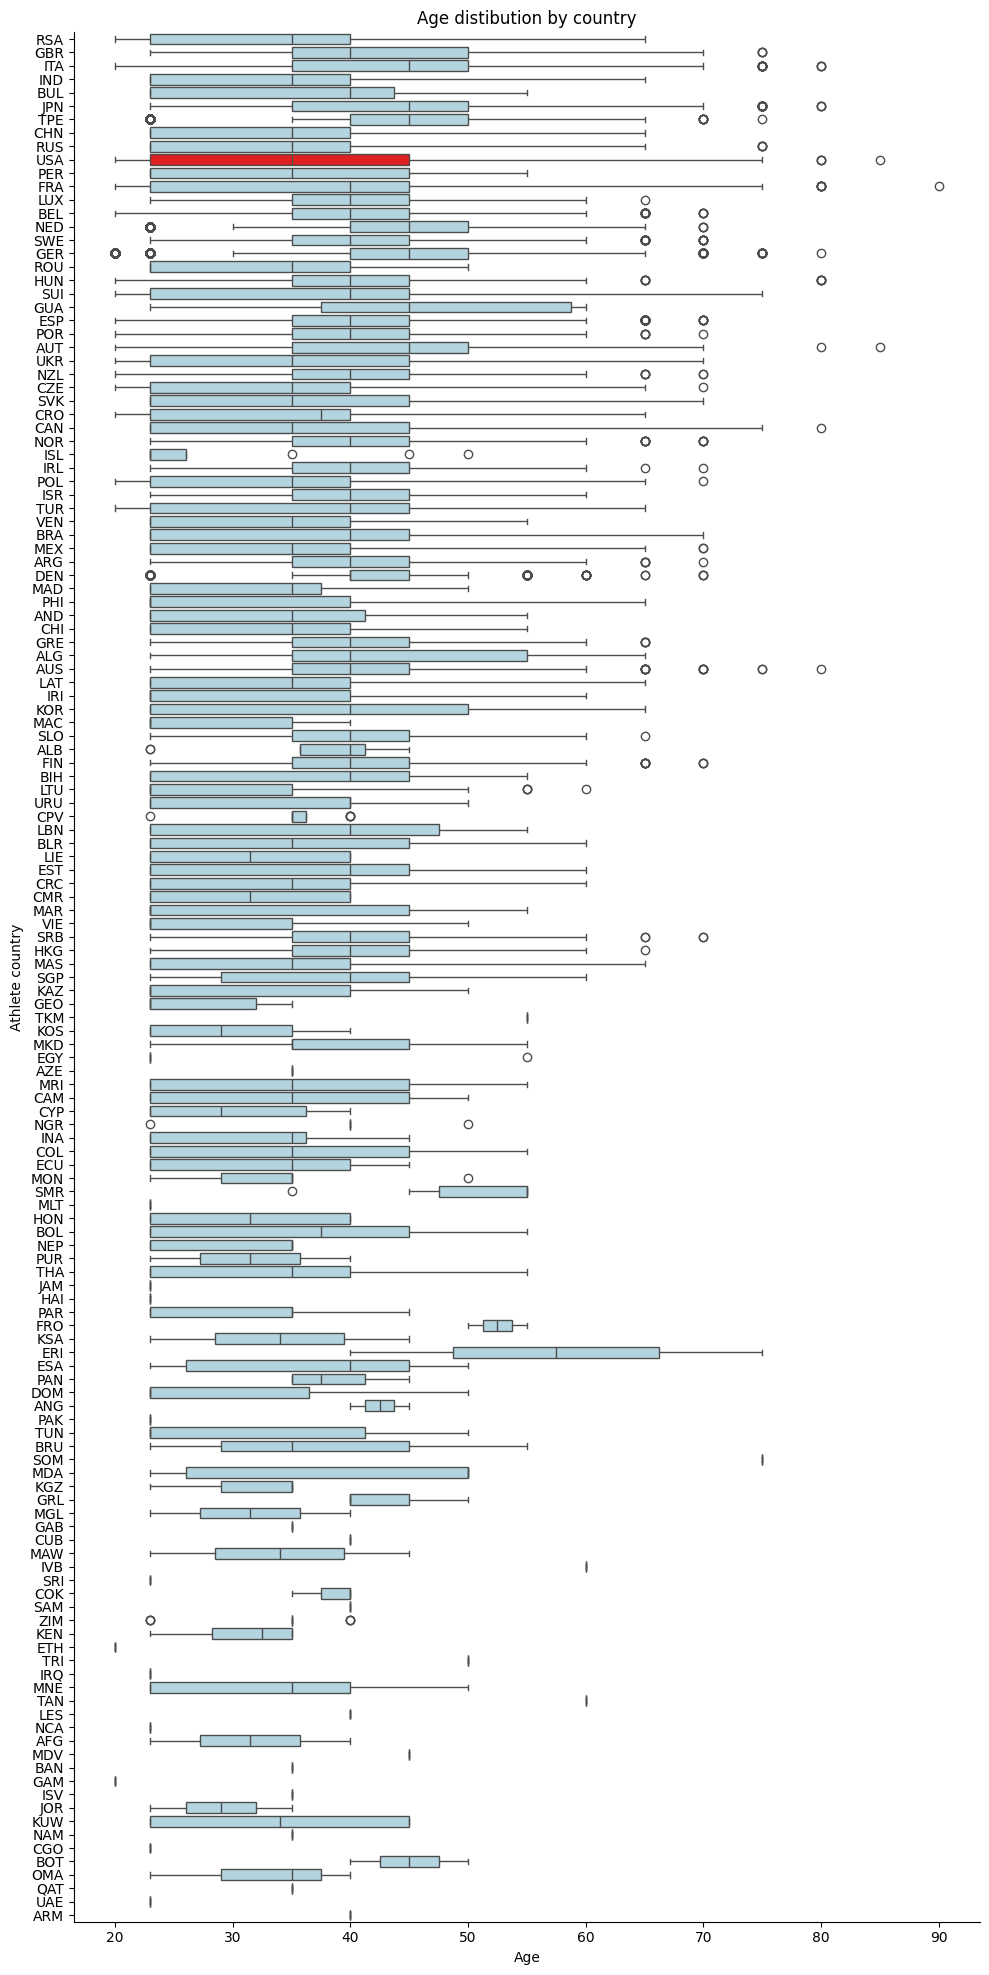

In [124]:
# use seaborn for less code and better handling of spacing

my_colors = {country: 'red' if country == 'USA' else 'lightblue'
             for country in um_df['Athlete country'].unique()}

fig, ax = plt.subplots(figsize=(10, 20))

sns.boxplot(x='Age', y='Athlete country', data=um_df, palette=my_colors)

plt.title('Age distibution by country')
plt.xlabel("Age")
plt.ylabel("Athlete country")


plt.suptitle("")

sns.despine(top=True, right=True)

plt.tight_layout()

plt.show()


<div class="alert alert-block alert-success">
<b>With there being numberous outliers, we find the coutry with the oldest, France,  and youngest, Austria,  participants</b> 
</div>

In [125]:
max_age = um_df.loc[um_df['Age'].idxmax()]
max_age

Year of event                                                     2016
Event dates                                                 2016-09-17
Event name                   Les 24 heures de St Maixent l'Ecole (FRA)
Event distance/length                                              24h
Event number of finishers                                           40
Athlete performance                                          78.790 km
Athlete club                                                    *Paris
Athlete country                                                    FRA
Athlete year of birth                                           1922.0
Athlete gender                                                       M
Athlete age category                                               M90
Athlete average speed                                            3.283
Athlete ID                                                      269221
Age                                                                 90
Age Br

In [126]:
min_age = um_df.loc[um_df['Age'].idxmin()]
min_age

Year of event                                                             2018
Event dates                                                         2018-09-15
Event name                   Sri Chinmoy Peace-Mile 6-Stunden Lauf München ...
Event distance/length                                                       6h
Event number of finishers                                                   55
Athlete performance                                                  68.458 km
Athlete club                                         Sri Chinmoy Marathon Team
Athlete country                                                            AUT
Athlete year of birth                                                   1992.0
Athlete gender                                                               M
Athlete age category                                                       M20
Athlete average speed                                                    11.41
Athlete ID                                          

In [127]:
um_df.to_csv('UM Age Brackets.csv', index=False)

In [128]:
um_df = pd.read_csv("Data/UM Age Brackets.csv")
um_df.head()

/var/folders/77/qj38nbbs3bq7mscbtmmv1lzw0000gn/T/ipykernel_16888/3910220909.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  um_df = pd.read_csv("Data/UM Age Brackets.csv")


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID,Age,Age Bracket
0,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:51 h,Team GG,RSA,1985.0,M,M23,5.381,266403,23,21-25
1,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:58 h,Team GG,GBR,1986.0,M,M23,5.381,266404,23,21-25
2,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:02 h,MAD Pat'S Brigade,GBR,1972.0,M,M45,4.386,266406,45,45-49
3,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:07 h,MAD Pat'S Brigade,GBR,1959.0,F,W55,4.386,266407,55,55-59
4,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:16:08 h,MAD Pat'S Brigade,GBR,1962.0,M,M55,4.368,266409,55,55-59


In [129]:
# add distance column to marathon df and fill with 26.2

def add_distance_column(df):
    df['Distande'] = 26.2
    return df

marathon_df = add_distance_column(marathon_df)



In [130]:
marathon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779280 entries, 0 to 779284
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Race         779280 non-null  object 
 1   Year         779280 non-null  int64  
 2   Name         779280 non-null  object 
 3   Sex          779280 non-null  object 
 4   Age          779280 non-null  int64  
 5   Finish       779280 non-null  int64  
 6   Age Bracket  779280 non-null  object 
 7   Distande     779280 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 53.5+ MB


In [131]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217562 entries, 0 to 217561
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              217562 non-null  int64  
 1   Event dates                217562 non-null  object 
 2   Event name                 217562 non-null  object 
 3   Event distance/length      217562 non-null  object 
 4   Event number of finishers  217562 non-null  int64  
 5   Athlete performance        217562 non-null  object 
 6   Athlete club               217562 non-null  object 
 7   Athlete country            217562 non-null  object 
 8   Athlete year of birth      217562 non-null  float64
 9   Athlete gender             217562 non-null  object 
 10  Athlete age category       217562 non-null  object 
 11  Athlete average speed      217562 non-null  object 
 12  Athlete ID                 217562 non-null  int64  
 13  Age                        21

In [132]:
# Finding how Age Brackets are formated inorder to join on Age Bracket later

um_df['Age Bracket'].unique().tolist()


['21-25',
 '45-49',
 '55-59',
 '35-39',
 '50-54',
 '60-64',
 '40-44',
 '65-69',
 '70-74',
 '85-89',
 '30-34',
 '75-79',
 '80-84',
 '90+']

In [133]:
marathon_df['Age Bracket'].unique().tolist()

['40-44',
 'Under 35',
 '55-59',
 '35-39',
 '60-64',
 '45-49',
 '50-54',
 '65-69',
 '70-74',
 '75-79',
 '80 and Over']

In [134]:
# Matching marathon df Age Bracket column to the ultra marathon df for the sql join

def marathon_to_um_age_match(age):
    if 17 <= age <= 20:
        return "17-20"
    if 21 <= age <= 25:
        return "21-25" 
    if 26 <= age <= 29:
        return "26-29"
    if 30 <= age <= 34:
        return "30-34" 
    if 35 <= age <= 39:
        return "35-39" 
    if 40 <= age <= 44:
        return "40-44"  
    if 45 <= age <= 49:
        return "45-49" 
    if 50 <= age <= 54:
        return "50-54" 
    if 55 <= age <= 59:
          return "55-59" 
    if 60 <= age <= 64:
          return "60-64" 
    if 65 <= age <= 69:
        return "65-69" 
    if 70 <= age <= 74:
        return "70-74" 
    if 75 <= age <= 79:
        return "75-79" 
    if 80 <= age <= 84:
        return "80-84" 
    if 85 <= age <= 89:
        return "85-89" 
    if age >= 90:
        return "90+" 
    return None

In [135]:
marathon_df["Age Bracket"] = marathon_df["Age"].apply(athlete_age_category)
um_df["Age Bracket"] = um_df["Age"].apply(athlete_age_category)

In [136]:
# Verify Age Bracket columns match

print("UM brackets:", sorted(um_df["Age Bracket"].unique()))


UM brackets: ['17-20', '21-25', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90+']


In [137]:
print("Marathon brackets:", sorted(marathon_df["Age Bracket"].dropna().unique()))

Marathon brackets: ['17-20', '21-25', '26-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90+']


In [138]:
with sqlite3.connect("marathon_and_ultra.db") as connection:
    cursor = connection.cursor()
    marathon_df.to_sql("marathon", connection, if_exists="replace", index=False)
    um_df.to_sql("um", connection, if_exists="replace", index=False)

<div class="alert alert-block alert-warning">
<b>Next we create a table for the marathon broken down by Age Bracket and the number of finishers per Age Bracket. Then we take the most common distances of ultra marathons and find the totals for each Age Bracket. Finially we join the 2 tables together to visually compare the Age Brackets by distance.  <b>
</div>

In [139]:
merge_on_age_bracket = """ 
WITH marathon_counts AS (
    SELECT "Age Bracket", COUNT(*) AS Marathon_Finishers
    FROM marathon
    GROUP BY "Age Bracket"
)
SELECT
    m."Age Bracket" AS Age_bracket,
    m.Marathon_Finishers,
    SUM(CASE WHEN u."Event distance/length" = '50km' THEN u."Event number of finishers" ELSE 0 END) AS "50km",
    SUM(CASE WHEN u."Event distance/length" = '50mi' THEN u."Event number of finishers" ELSE 0 END) AS "50m",
    SUM(CASE WHEN u."Event distance/length" = '100km' THEN u."Event number of finishers" ELSE 0 END) AS "100km",
    SUM(CASE WHEN u."Event distance/length" = '100mi' THEN u."Event number of finishers" ELSE 0 END) AS "100m"
FROM marathon_counts AS m
LEFT JOIN um AS u
    ON m."Age Bracket" = u."Age Bracket"
GROUP BY m."Age Bracket", m.Marathon_Finishers
ORDER BY m."Age Bracket" ASC;
    """
merge_on_age_bracket = pd.read_sql(merge_on_age_bracket, connection)
merge_on_age_bracket

,Age_bracket,Marathon_Finishers,50km,50m,100km,100m
0,17-20,7938,36346,0,56,0
1,21-25,52800,3215434,1324281,1413644,28
2,26-29,90840,0,0,0,0
3,30-34,112591,36337,0,115,0
4,35-39,121442,2073439,733947,1415114,31
5,40-44,116933,2053456,663054,1980645,110
6,45-49,101041,1799640,564333,2031436,152
7,50-54,75459,1154119,367036,1660349,61
8,55-59,45487,646406,210058,1053356,31
9,60-64,23684,332935,105525,498603,46


<div class="alert alert-block alert-warning">
<b>Next we show the percentage of each age group by marathon and ultra marathon based off of the above table.  <b>
</div>

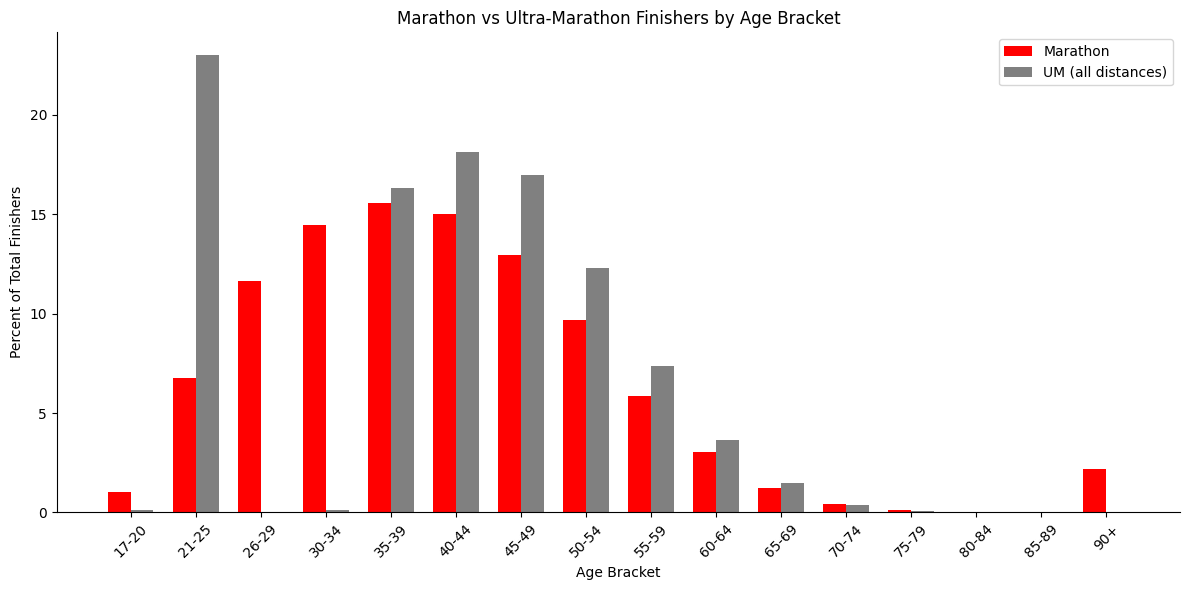

In [140]:
merge_on_age_bracket['UM_Finishers'] = merge_on_age_bracket[['50km', '50m', '100km', '100m']].sum(axis=1)


total_marathon_finishers = merge_on_age_bracket['Marathon_Finishers'].sum()
total_um_finishers = merge_on_age_bracket['UM_Finishers'].sum()

merge_on_age_bracket['Marathon_Percent'] = merge_on_age_bracket['Marathon_Finishers'] / total_marathon_finishers * 100
merge_on_age_bracket['UM_Percent'] = merge_on_age_bracket['UM_Finishers'] / total_um_finishers * 100

age_brackets = merge_on_age_bracket['Age_bracket']
x = np.arange(len(age_brackets))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, merge_on_age_bracket['Marathon_Percent'], width, label='Marathon', color='red')
ax.bar(x + width/2, merge_on_age_bracket['UM_Percent'], width, label='UM (all distances)', color='grey')

ax.set_xlabel('Age Bracket')
ax.set_ylabel('Percent of Total Finishers')
ax.set_title('Marathon vs Ultra-Marathon Finishers by Age Bracket')
ax.set_xticks(x)
ax.set_xticklabels(age_brackets, rotation=45)
ax.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
plt.show()


<div class="alert alert-block alert-warning">
<b>From the above graph we can see that the marathon had a higher percentage of parcipants aged 17-20, 70-74, 75-79, and 90+, while the ultra marathon had a higher percentage of middle aged to early medicare elligible adults.<b>
</div>